In [ ]:
# 1. 나눔 폰트 설치
!apt-get install -y fonts-nanum
!fc-cache -fv

# 2. 설치 후 실행 중인 프로세스가 폰트를 인식하도록 matplotlib 캐시 삭제
import matplotlib as mpl
mpl.font_manager._rebuild() if hasattr(mpl.font_manager, '_rebuild') else None

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

  환경 설정 완료
  pandas   : 2.2.2
  numpy    : 2.0.2
  폰트     : ['NanumGothic']
  K-Fold   : 5
  시드값   : 42


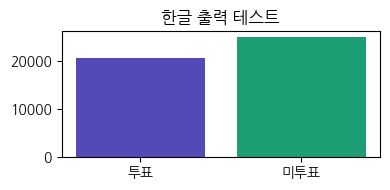


  위 그래프에 한글이 보이면 설정 완료!
  → 다음 셀: step1_EDA.py


In [ ]:
# ── 2. 라이브러리 import ──────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score

# ── 3. 한글 폰트 설정 ─────────────────────────
fm._load_fontmanager(try_read_cache=False)
plt.rcParams['font.family']        = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 4. 공통 색상 팔레트 ───────────────────────
COLOR_MAIN = '#534AB7'   # 보라  (투표 / 주요)
COLOR_SUB  = '#1D9E75'   # 초록  (미투표 / 보조)
COLOR_WARN = '#D85A30'   # 주황  (경고 / 역코딩)
COLOR_GRAY = '#888780'   # 회색  (중립)

# ── 5. 공통 설정값 ────────────────────────────
N_SPLITS     = 5           # K-Fold 분할 수
RANDOM_STATE = 42          # 재현성 고정
TARGET       = 'voted'     # 예측 대상 컬럼

# ── 6. 확인 출력 ──────────────────────────────
print("=" * 45)
print("  환경 설정 완료")
print("=" * 45)
print(f"  pandas   : {pd.__version__}")
print(f"  numpy    : {np.__version__}")
print(f"  폰트     : {plt.rcParams['font.family']}")
print(f"  K-Fold   : {N_SPLITS}")
print(f"  시드값   : {RANDOM_STATE}")

# ── 7. 한글 테스트 ────────────────────────────
fig, ax = plt.subplots(figsize=(4, 2))
ax.bar(['투표', '미투표'], [20634, 24898],
       color=[COLOR_MAIN, COLOR_SUB])
ax.set_title('한글 출력 테스트')
plt.tight_layout()
plt.show()
print("\n  위 그래프에 한글이 보이면 설정 완료!")
print("  → 다음 셀: step1_EDA.py")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.8 MB/s eta 0:00:00
라이브러리 로드 완료
타겟 분포: {1: np.int64(24898), 0: np.int64(20634)}


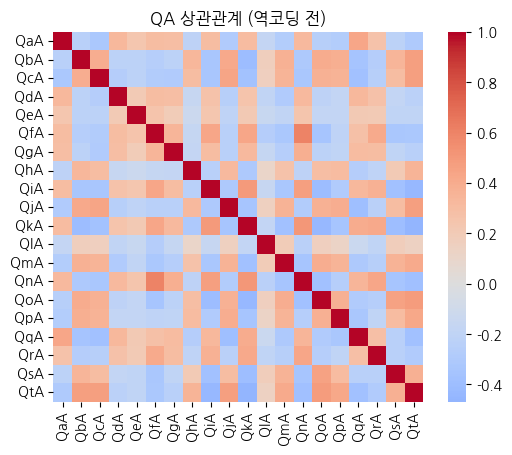

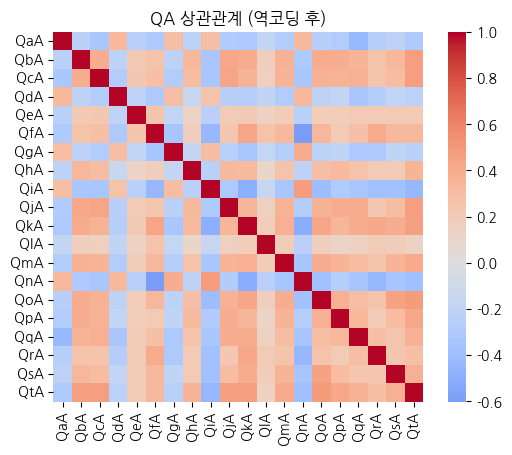

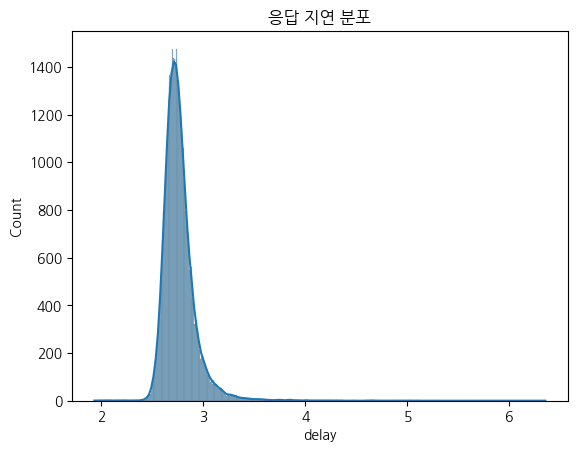

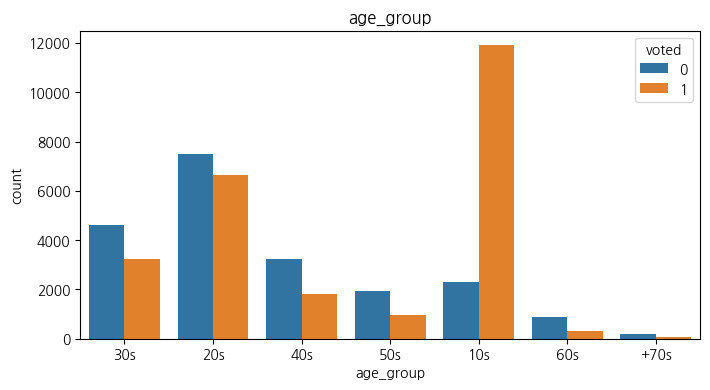

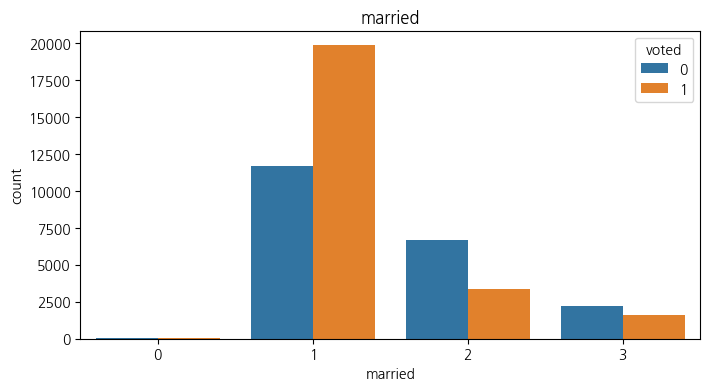

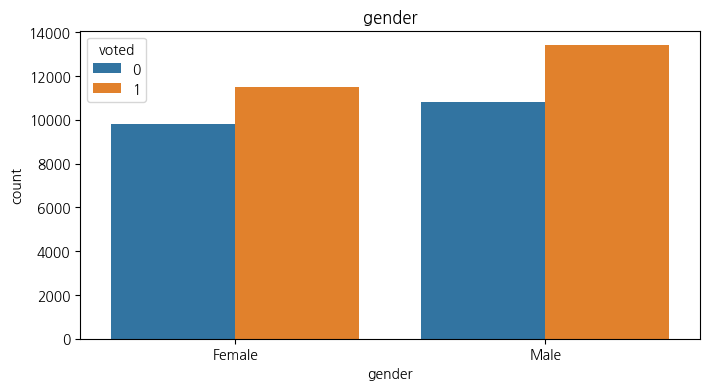

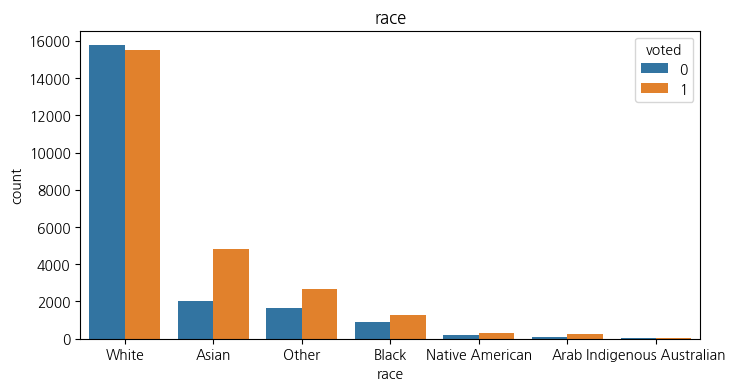

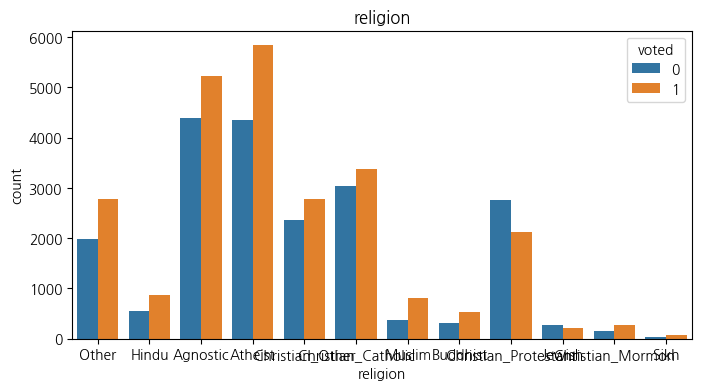

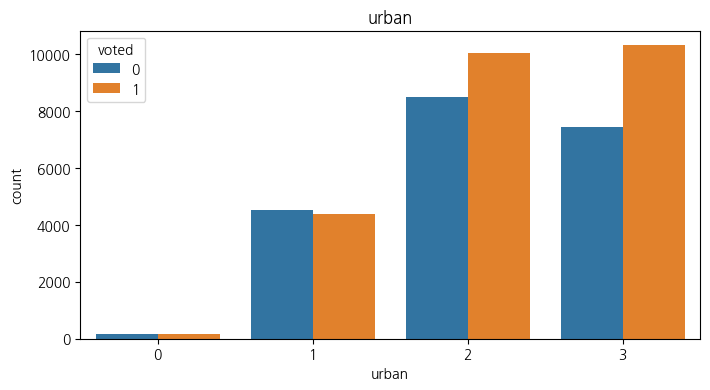

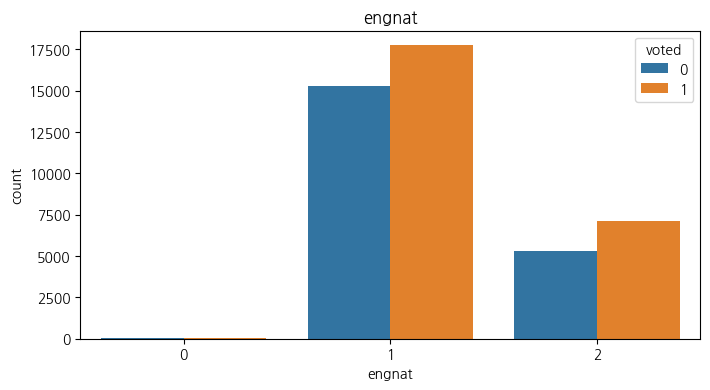

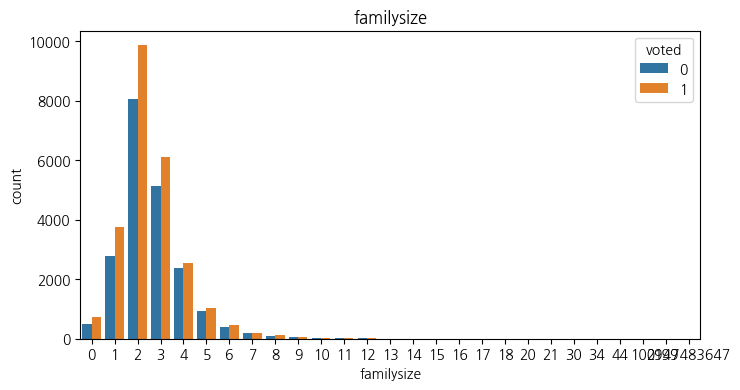

In [ ]:
!pip install lightgbm optuna -q

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import random
import gc
from string import ascii_lowercase
from itertools import combinations

import lightgbm as lgb
from lightgbm import LGBMClassifier, early_stopping
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.metrics import roc_auc_score
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

warnings.filterwarnings('ignore')
DATA_DIR = '/content'

TARGET    = 'voted'
QUESTIONS = list(ascii_lowercase[:20])
ANSWERS   = [f'Q{q}A' for q in QUESTIONS]
DELAYS    = [f'Q{q}E' for q in QUESTIONS]
TPS       = [f'tp{str(i).zfill(2)}' for i in range(1, 11)]
NEEDENCO  = ['age_group', 'gender', 'race', 'religion']

# 역코딩 대상 문항
NEG_ITEMS_MACH = ['QeA', 'QfA', 'QkA', 'QqA', 'QrA']
NEG_ITEMS_BIG5 = ['QaA', 'QdA', 'QgA', 'QiA', 'QnA']

print('라이브러리 로드 완료')


# ══════════════════════════════════════════════════════════════
# Part 1 — EDA
# ══════════════════════════════════════════════════════════════

train = pd.read_csv(f'{DATA_DIR}/train.csv')
test  = pd.read_csv(f'{DATA_DIR}/test_x.csv')

train[TARGET] = train[TARGET].map({1: 0, 2: 1})
y_eda = train[TARGET].values
print(f'타겟 분포: {dict(pd.Series(y_eda).value_counts())}')

eda_train = train.copy()
correlations = eda_train[ANSWERS].corr(method='spearman')
sns.heatmap(correlations, cmap='coolwarm', square=True, center=0)
plt.title('QA 상관관계 (역코딩 전)')
plt.show()

for flip in NEG_ITEMS_MACH:
    eda_train[flip] = 6 - eda_train[flip]

correlations = eda_train[ANSWERS].corr(method='spearman')
sns.heatmap(correlations, cmap='coolwarm', square=True, center=0)
plt.title('QA 상관관계 (역코딩 후)')
plt.show()

eda_train['delay'] = eda_train[DELAYS].sum(axis=1) ** (1 / 10)
sns.histplot(eda_train['delay'], kde=True)
plt.title('응답 지연 분포')
plt.show()

for col in ['age_group', 'married', 'gender', 'race', 'religion', 'urban', 'engnat', 'familysize']:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=eda_train, x=col, hue=TARGET)
    plt.title(col)
    plt.show()


# ══════════════════════════════════════════════════════════════
# 공통 피처 엔지니어링 함수 (강화)
# ══════════════════════════════════════════════════════════════

def build_features_m1(df_list):
    """Model 1 피처 엔지니어링"""
    for data in df_list:
        data['T'] = data['QcA'] - data['QfA'] + data['QoA'] - data['QrA'] + data['QsA']
        data['V'] = data['QbA'] - data['QeA'] + data['QhA'] + data['QjA'] + data['QmA'] - data['QqA']
        data['M'] = -data['QkA']

        for flip in NEG_ITEMS_MACH:
            data[flip] = 6 - data[flip]
        for flip in NEG_ITEMS_BIG5:
            data[flip] = 6 - data[flip]

        data['Mach_score'] = data[ANSWERS].mean(axis=1)
        data['delay']      = data[DELAYS].sum(axis=1) ** (1 / 10)

        for a, b in combinations(ANSWERS, 2):
            data[f'{a}_dv_{b}'] = data[a] / data[b].replace(0, 1e-9)

        data.drop(ANSWERS + DELAYS, axis=1, inplace=True)
        data.drop('hand', axis=1, inplace=True)

        wr_list = [f'wr_0{i}' for i in range(1, 10)] + [f'wr_{i}' for i in range(10, 14)]
        wr_keep = ['wr_01', 'wr_03', 'wr_06', 'wr_09', 'wr_11']
        data.drop([c for c in wr_list if c not in wr_keep], axis=1, inplace=True)

        data['Ex']  = data['tp01'] - data['tp06']
        data['Ag']  = data['tp07'] - data['tp02']
        data['Con'] = data['tp03'] - data['tp08']
        data['Es']  = data['tp09'] - data['tp04']
        data['Op']  = data['tp05'] - data['tp10']
        data.drop([f'tp0{i}' for i in range(1, 10)] + ['tp10'], axis=1, inplace=True)


def build_features_m2(df_list):
    """
    Model 2 피처 엔지니어링 (강화)
    개선 사항:
      - 마키아벨리즘 하위척도 세분화 (T/V/M 각각 정규화)
      - Big Five 비율·합산 피처 추가
      - 응답 지연 통계 피처 (max, std, skew) 추가
      - 연령 구간 × 마키아벨리즘 교호작용
      - 응답 일관성(표준편차) 피처
    """
    for data in df_list:
        # ── 마키아벨리즘 하위척도 ──────────────────────────────────
        data['T'] = data['QcA'] - data['QfA'] + data['QoA'] - data['QrA'] + data['QsA']
        data['V'] = data['QbA'] - data['QeA'] + data['QhA'] + data['QjA'] + data['QmA'] - data['QqA']
        data['M'] = -data['QkA']

        for flip in NEG_ITEMS_MACH:
            data[flip] = 6 - data[flip]
        for flip in NEG_ITEMS_BIG5:
            data[flip] = 6 - data[flip]

        data['Mach_score'] = data[ANSWERS].mean(axis=1)
        data['mach_var']   = data[ANSWERS].var(axis=1)
        data['mach_std']   = data[ANSWERS].std(axis=1)           # ★ 추가: 응답 일관성
        data['mach_min']   = data[ANSWERS].min(axis=1)           # ★ 추가
        data['mach_max']   = data[ANSWERS].max(axis=1)           # ★ 추가
        data['mach_range'] = data['mach_max'] - data['mach_min'] # ★ 추가

        # ── 응답 지연 통계 ─────────────────────────────────────────
        data['delay']      = data[DELAYS].sum(axis=1) ** (1 / 10)
        data['delay_log']  = np.log1p(data['delay'])
        data['delay_max']  = data[DELAYS].max(axis=1)            # ★ 추가
        data['delay_std']  = data[DELAYS].std(axis=1)            # ★ 추가
        data['delay_skew'] = data[DELAYS].skew(axis=1)           # ★ 추가

        # ── QA 쌍 비율 피처 ────────────────────────────────────────
        for a, b in combinations(ANSWERS, 2):
            data[f'mach_{a}_dv_{b}'] = data[a] / data[b].replace(0, 1e-9)

        # ── Big Five ───────────────────────────────────────────────
        for tp in TPS:
            data[tp] = 7 - data[tp]
            data[tp] = data[tp].replace(0, np.nan).fillna(data[tp].mean())

        data['Ex']  = data['tp01'] - data['tp06']
        data['Ag']  = data['tp07'] - data['tp02']
        data['Con'] = data['tp03'] - data['tp08']
        data['Es']  = data['tp09'] - data['tp04']
        data['Op']  = data['tp05'] - data['tp10']

        # ★ Big Five 합산·비율 피처
        big5 = ['Ex', 'Ag', 'Con', 'Es', 'Op']
        data['big5_sum']  = data[big5].sum(axis=1)
        data['big5_mean'] = data[big5].mean(axis=1)
        for a, b in combinations(big5, 2):
            data[f'b5_{a}_dv_{b}'] = data[a] / (data[b].replace(0, 1e-9))

        # ── TP 쌍 비율 피처 ────────────────────────────────────────
        for a, b in combinations(TPS, 2):
            data[f'tp_{a}_dv_{b}'] = data[a] / data[b].replace(0, 1e-9)

        # ── 기타 파생 피처 ─────────────────────────────────────────
        data['teenager_ox']    = (data['age_group'] == '10s').astype(int)

        # ★ 마키아벨리즘 × 연령대 교호작용
        age_map = {'10s': 1, '20s': 2, '30s': 3, '40s': 4, '50s': 5, '60s': 6}
        data['age_num']        = data['age_group'].map(age_map).fillna(3)
        data['mach_x_age']     = data['Mach_score'] * data['age_num']

        # ★ 마키아벨리즘 × Es 교호작용 (투표 행동 관련)
        data['mach_x_Es']      = data['Mach_score'] * data['Es']
        data['mach_x_Con']     = data['Mach_score'] * data['Con']














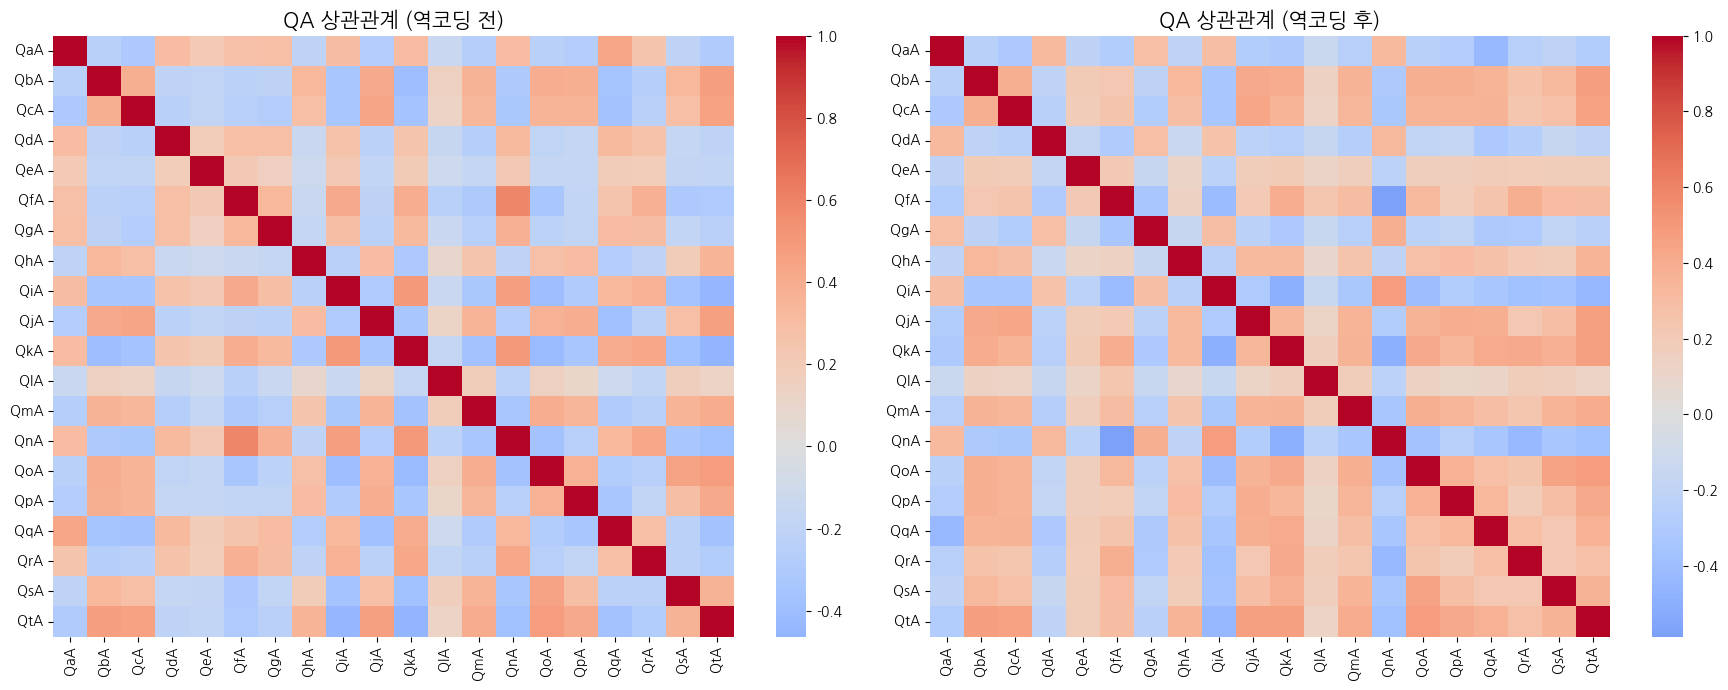

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 준비 (역코딩 전 복사본 생성)
eda_before = train[ANSWERS].copy()
eda_after = train[ANSWERS].copy()

# 2. 역코딩 실행 (After 데이터만)
for flip in NEG_ITEMS_MACH:
    eda_after[flip] = 6 - eda_after[flip]

# 3. 시각화 (서브플롯 활용)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 역코딩 전 히트맵
sns.heatmap(eda_before.corr(), cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('QA 상관관계 (역코딩 전)', fontsize=15)

# 역코딩 후 히트맵
sns.heatmap(eda_after.corr(), cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('QA 상관관계 (역코딩 후)', fontsize=15)

plt.tight_layout()
plt.show()

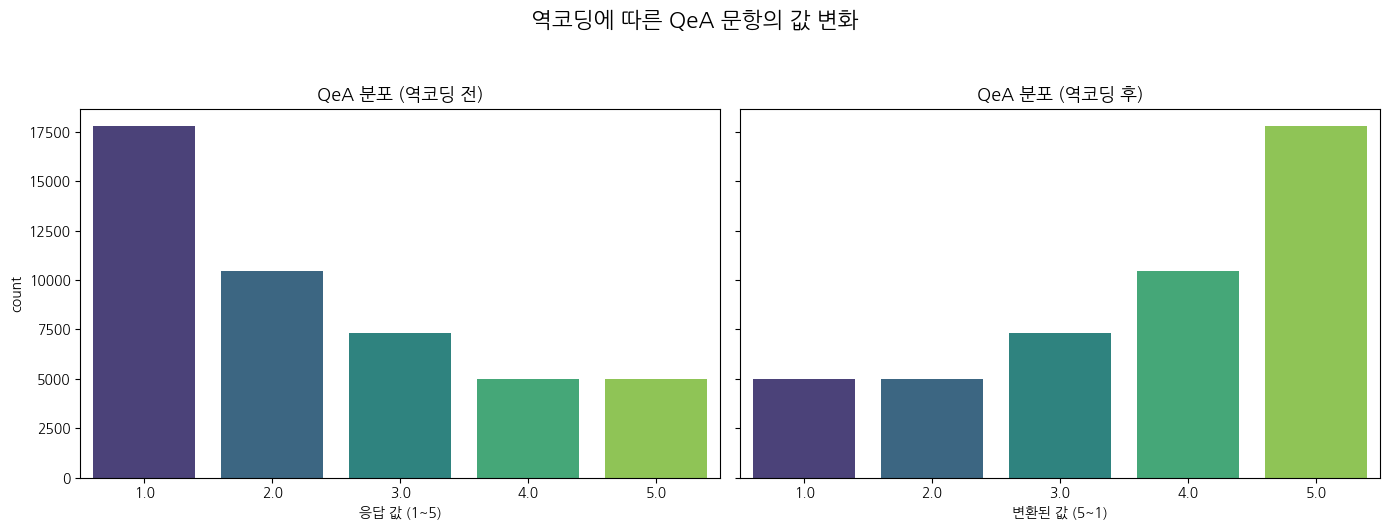

In [ ]:
target_col = 'QeA' # 역방향 문항 중 하나

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# 역코딩 전 분포
sns.countplot(x=eda_before[target_col], ax=axes[0], palette='viridis')
axes[0].set_title(f'{target_col} 분포 (역코딩 전)', fontsize=13)
axes[0].set_xlabel('응답 값 (1~5)')

# 역코딩 후 분포
sns.countplot(x=eda_after[target_col], ax=axes[1], palette='viridis')
axes[1].set_title(f'{target_col} 분포 (역코딩 후)', fontsize=13)
axes[1].set_xlabel('변환된 값 (5~1)')

plt.suptitle(f'역코딩에 따른 {target_col} 문항의 값 변화', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

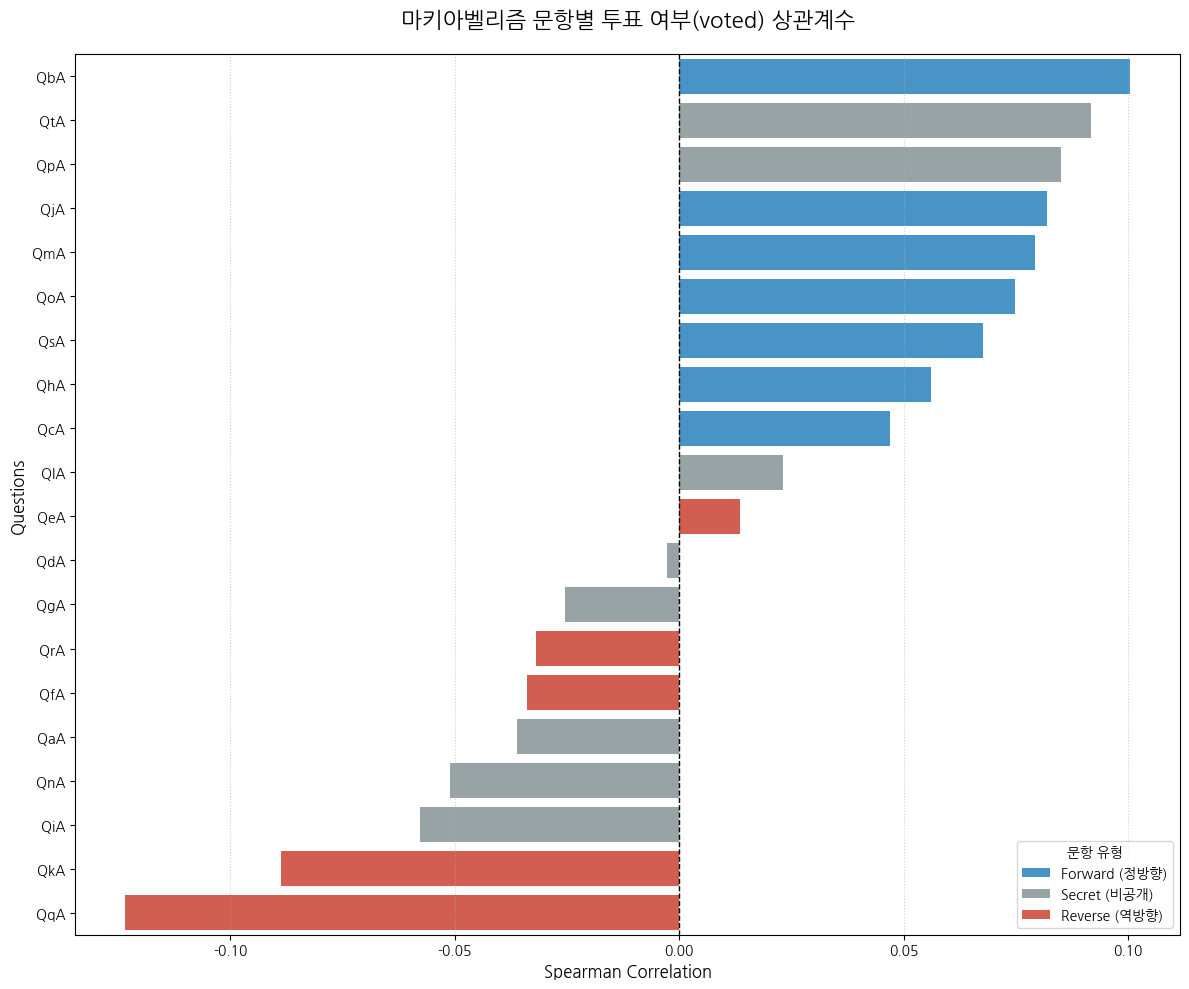

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 문항 그룹 정의
FORWARD = ['QbA', 'QcA', 'QhA', 'QjA', 'QmA', 'QoA', 'QsA']
REVERSE = ['QeA', 'QfA', 'QkA', 'QqA', 'QrA']
SECRET  = ['QaA', 'QdA', 'QgA', 'QiA', 'QlA', 'QnA', 'QpA', 'QtA']
ALL_Q   = sorted(FORWARD + REVERSE + SECRET)

# 2. 상관계수 계산 (역코딩 전 원본 데이터 기준)
# train 데이터와 TARGET('voted')이 정의되어 있어야 합니다.
correlations = train[ALL_Q].corrwith(train[TARGET], method='spearman').reset_index()
correlations.columns = ['Feature', 'Corr']

# 3. 그룹 라벨링 함수
def get_group(x):
    if x in FORWARD: return 'Forward (정방향)'
    if x in REVERSE: return 'Reverse (역방향)'
    return 'Secret (비공개)'

correlations['Group'] = correlations['Feature'].apply(get_group)
correlations = correlations.sort_values(by='Corr', ascending=False)

# 4. 시각화
plt.figure(figsize=(12, 10))
palette = {'Forward (정방향)': '#3498db', 'Reverse (역방향)': '#e74c3c', 'Secret (비공개)': '#95a5a6'}

sns.barplot(data=correlations, x='Corr', y='Feature', hue='Group', dodge=False, palette=palette)

plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('마키아벨리즘 문항별 투표 여부(voted) 상관계수', fontsize=16, pad=20)
plt.xlabel('Spearman Correlation', fontsize=12)
plt.ylabel('Questions', fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.legend(title='문항 유형', loc='lower right')

plt.tight_layout()
plt.show()

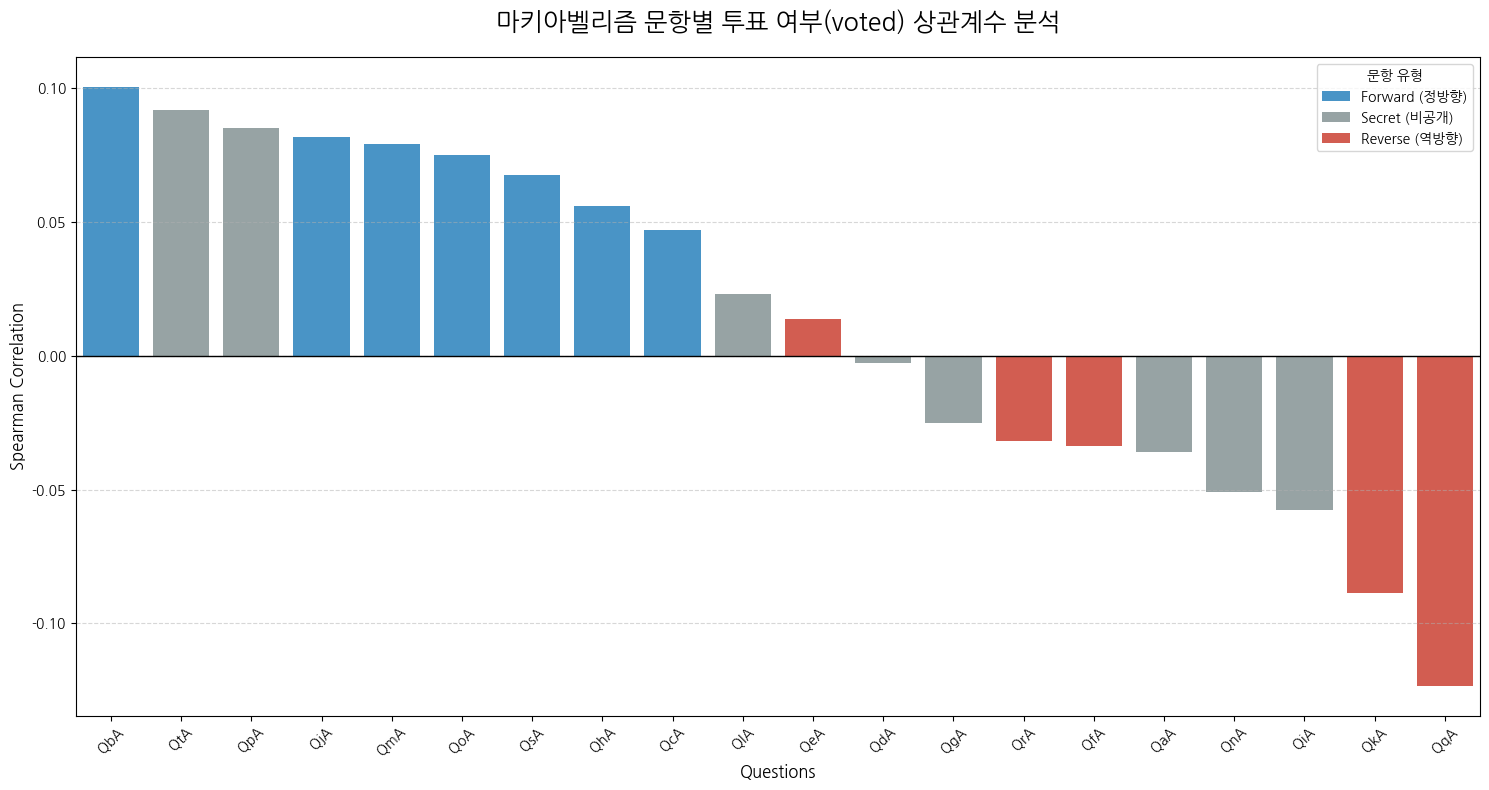

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 문항 그룹 정의 (제공해주신 리스트 기반)
FORWARD = ['QbA', 'QcA', 'QhA', 'QjA', 'QmA', 'QoA', 'QsA']
REVERSE = ['QeA', 'QfA', 'QkA', 'QqA', 'QrA']
SECRET  = ['QaA', 'QdA', 'QgA', 'QiA', 'QlA', 'QnA', 'QpA', 'QtA']
ALL_Q   = FORWARD + REVERSE + SECRET

# 2. 상관계수 계산 (역코딩 전 원본 데이터 기준)
# train 데이터와 TARGET 변수가 사전 정의되어 있어야 합니다.
correlations = train[ALL_Q].corrwith(train[TARGET], method='spearman').reset_index()
correlations.columns = ['Feature', 'Corr']

# 3. 그룹 라벨링
def get_group(x):
    if x in FORWARD: return 'Forward (정방향)'
    if x in REVERSE: return 'Reverse (역방향)'
    return 'Secret (비공개)'

correlations['Group'] = correlations['Feature'].apply(get_group)

# 시각적인 정돈을 위해 상관계수 값 순으로 정렬
correlations = correlations.sort_values(by='Corr', ascending=False)

# 4. 시각화 (위쪽을 향하는 세로 막대 그래프)
plt.figure(figsize=(15, 8))
palette = {'Forward (정방향)': '#3498db', 'Reverse (역방향)': '#e74c3c', 'Secret (비공개)': '#95a5a6'}

sns.barplot(data=correlations, x='Feature', y='Corr', hue='Group',
            dodge=False, palette=palette)

# 가이드 라인 추가
plt.axhline(0, color='black', linestyle='-', linewidth=1) # 기준선
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 축 및 제목 설정
plt.title('마키아벨리즘 문항별 투표 여부(voted) 상관계수 분석', fontsize=18, pad=20)
plt.ylabel('Spearman Correlation', fontsize=12)
plt.xlabel('Questions', fontsize=12)
plt.xticks(rotation=45) # 문항 이름이 겹치지 않게 회전
plt.legend(title='문항 유형', loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
# [After] 역코딩 적용 후 상관계수 계산 부분 수정
train_after = train.copy()

# 1. 명시적 역방향 문항 처리
for col in REVERSE:
    train_after[col] = 6 - train_after[col]

# 2. 비공개 문항 중 음의 상관관계를 보이는 문항 자동 처리
for col in SECRET:
    # 타겟(voted)과의 상관계수가 0보다 작으면 뒤집기
    if train[col].corr(train[TARGET], method='spearman') < 0:
        train_after[col] = 6 - train_after[col]
        print(f"비공개 문항 {col}이 음수이므로 통계적 역코딩을 적용했습니다.")

비공개 문항 QaA이 음수이므로 통계적 역코딩을 적용했습니다.
비공개 문항 QdA이 음수이므로 통계적 역코딩을 적용했습니다.
비공개 문항 QgA이 음수이므로 통계적 역코딩을 적용했습니다.
비공개 문항 QiA이 음수이므로 통계적 역코딩을 적용했습니다.
비공개 문항 QnA이 음수이므로 통계적 역코딩을 적용했습니다.


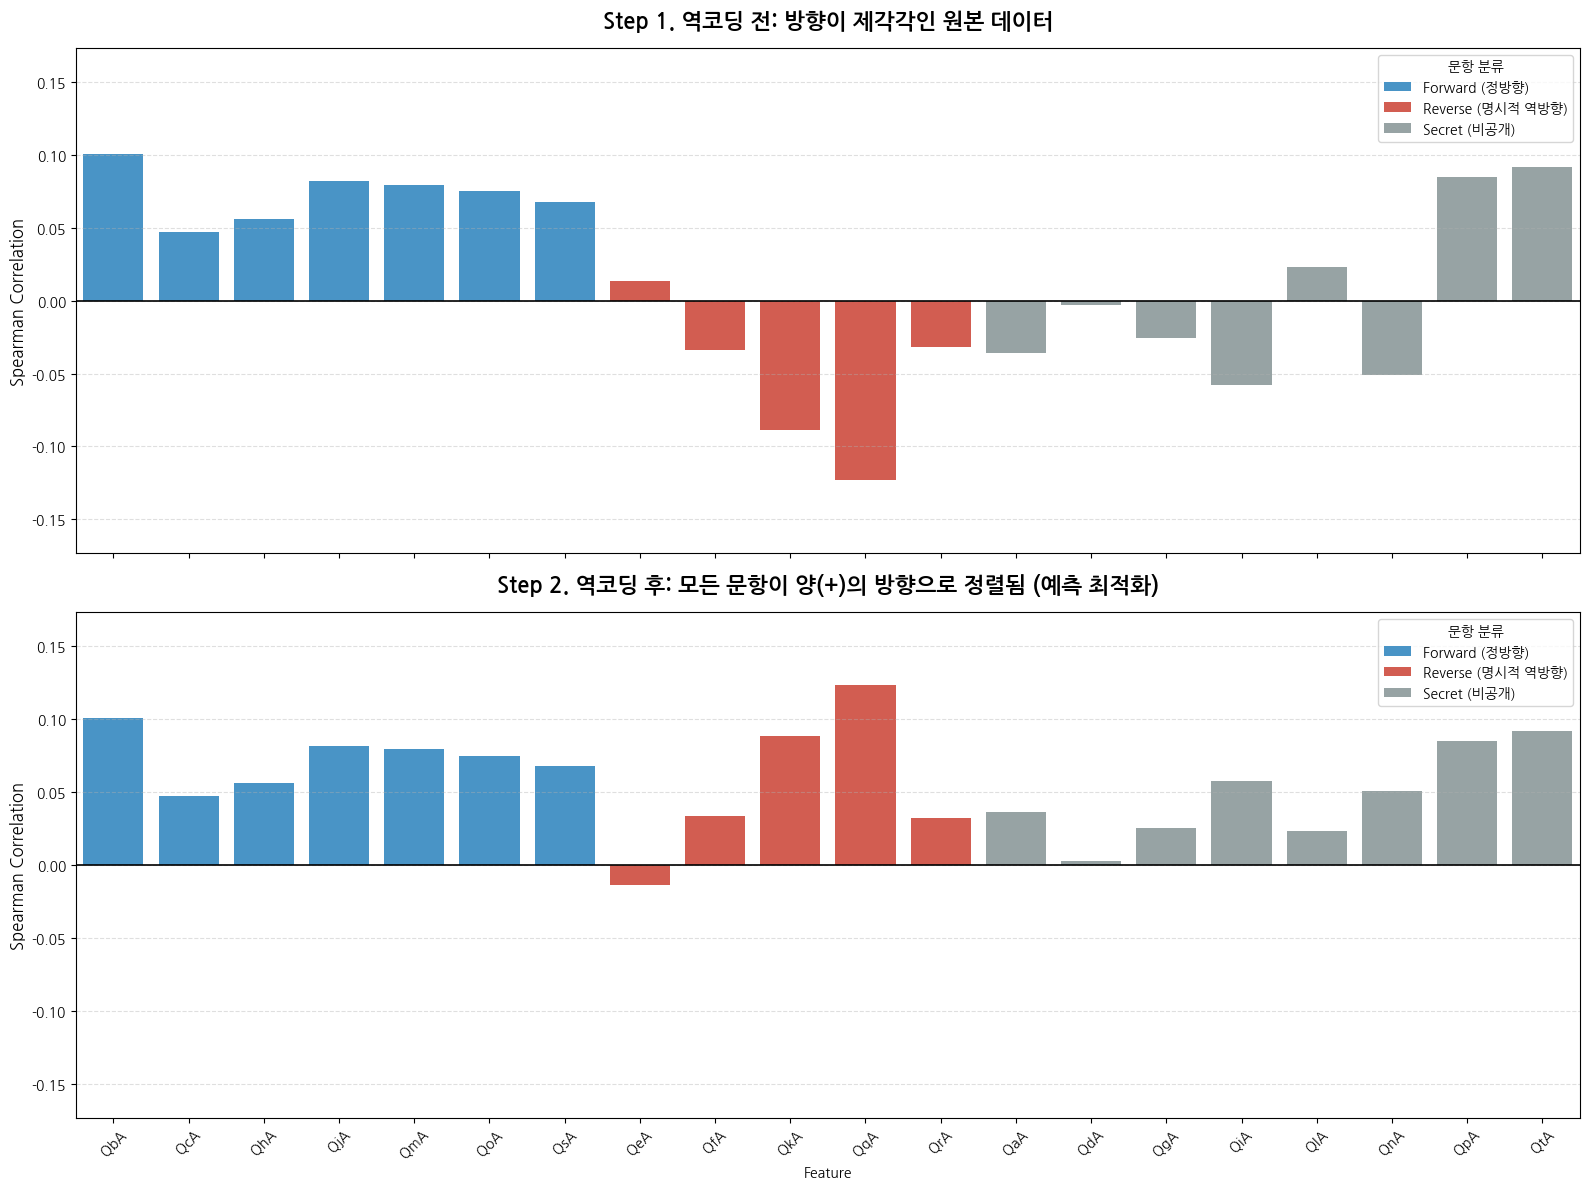

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 문항 그룹 정의
FORWARD = ['QbA', 'QcA', 'QhA', 'QjA', 'QmA', 'QoA', 'QsA']
REVERSE = ['QeA', 'QfA', 'QkA', 'QqA', 'QrA']
SECRET  = ['QaA', 'QdA', 'QgA', 'QiA', 'QlA', 'QnA', 'QpA', 'QtA']
ALL_Q   = FORWARD + REVERSE + SECRET

# 2. 데이터 준비 (역코딩 전/후 상관계수 계산)

# [Before] 원본 상태
df_before = train[ALL_Q].corrwith(train[TARGET], method='spearman').reset_index()
df_before.columns = ['Feature', 'Corr']
df_before['Status'] = 'Before (역코딩 전)'

# [After] 역코딩 적용 (REVERSE + 음수 상관관계 SECRET 문항)
train_after = train.copy()

# (1) 명시적 역방향 문항 뒤집기
for col in REVERSE:
    train_after[col] = 6 - train_after[col]

# (2) 비공개 문항 중 음수인 것들 찾아 통계적으로 뒤집기
for col in SECRET:
    if train[col].corr(train[TARGET], method='spearman') < 0:
        train_after[col] = 6 - train_after[col]

df_after = train_after[ALL_Q].corrwith(train_after[TARGET], method='spearman').reset_index()
df_after.columns = ['Feature', 'Corr']
df_after['Status'] = 'After (역코딩 후)'

# 데이터 통합 및 그룹화
df_total = pd.concat([df_before, df_after])
def get_group(x):
    if x in FORWARD: return 'Forward (정방향)'
    if x in REVERSE: return 'Reverse (명시적 역방향)'
    return 'Secret (비공개)'
df_total['Group'] = df_total['Feature'].apply(get_group)

# 3. 시각화 (두 상태를 위아래로 배치)
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)
palette = {'Forward (정방향)': '#3498db', 'Reverse (명시적 역방향)': '#e74c3c', 'Secret (비공개)': '#95a5a6'}

# 위: Before
sns.barplot(data=df_total[df_total['Status'] == 'Before (역코딩 전)'],
            x='Feature', y='Corr', hue='Group', palette=palette, ax=axes[0], dodge=False)
axes[0].set_title('Step 1. 역코딩 전: 방향이 제각각인 원본 데이터', fontsize=16, fontweight='bold', pad=15)
axes[0].axhline(0, color='black', linewidth=1.2)
axes[0].set_ylim(df_total['Corr'].min() - 0.05, df_total['Corr'].max() + 0.05)

# 아래: After
sns.barplot(data=df_total[df_total['Status'] == 'After (역코딩 후)'],
            x='Feature', y='Corr', hue='Group', palette=palette, ax=axes[1], dodge=False)
axes[1].set_title('Step 2. 역코딩 후: 모든 문항이 양(+)의 방향으로 정렬됨 (예측 최적화)', fontsize=16, fontweight='bold', pad=15)
axes[1].axhline(0, color='black', linewidth=1.2)
axes[1].set_ylim(df_total['Corr'].min() - 0.05, df_total['Corr'].max() + 0.05)

# 공통 레이아웃 설정
for ax in axes:
    ax.set_ylabel('Spearman Correlation', fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.legend(title='문항 분류', loc='upper right')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

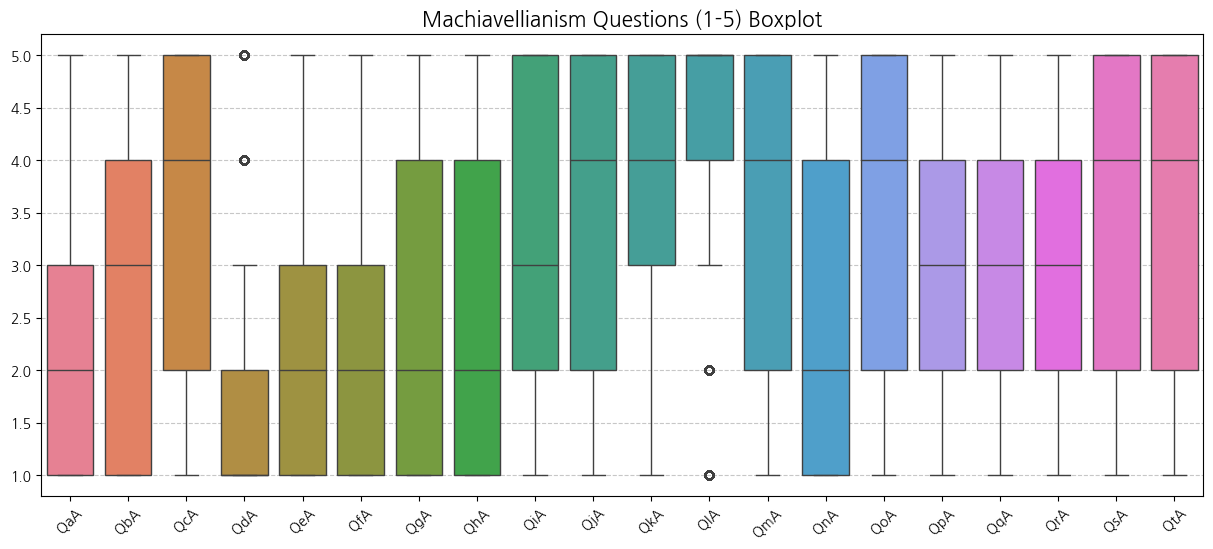

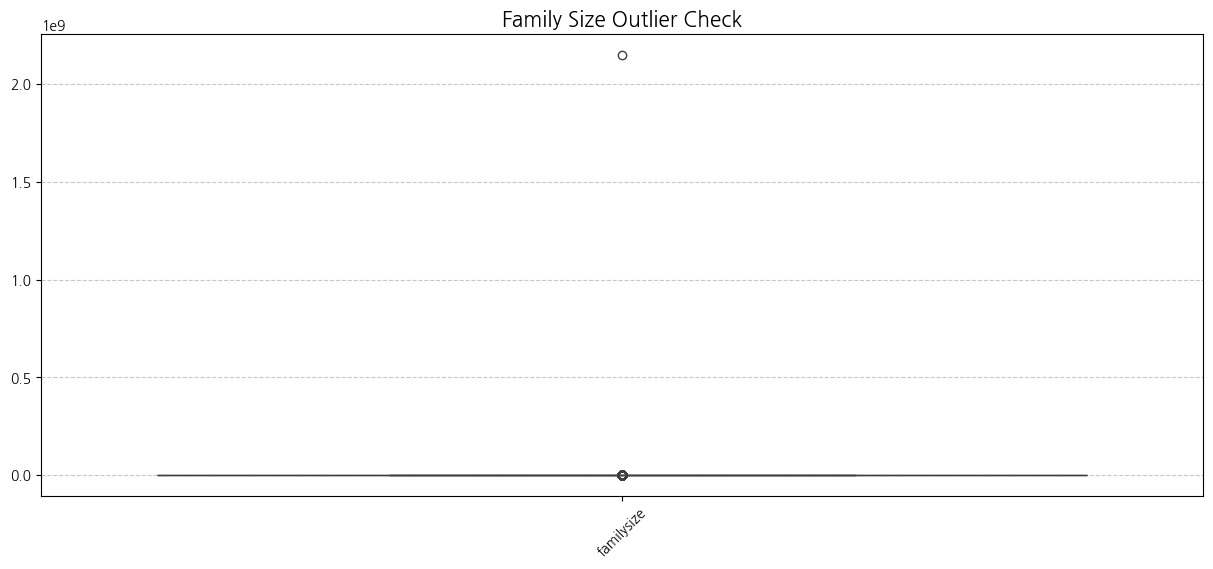

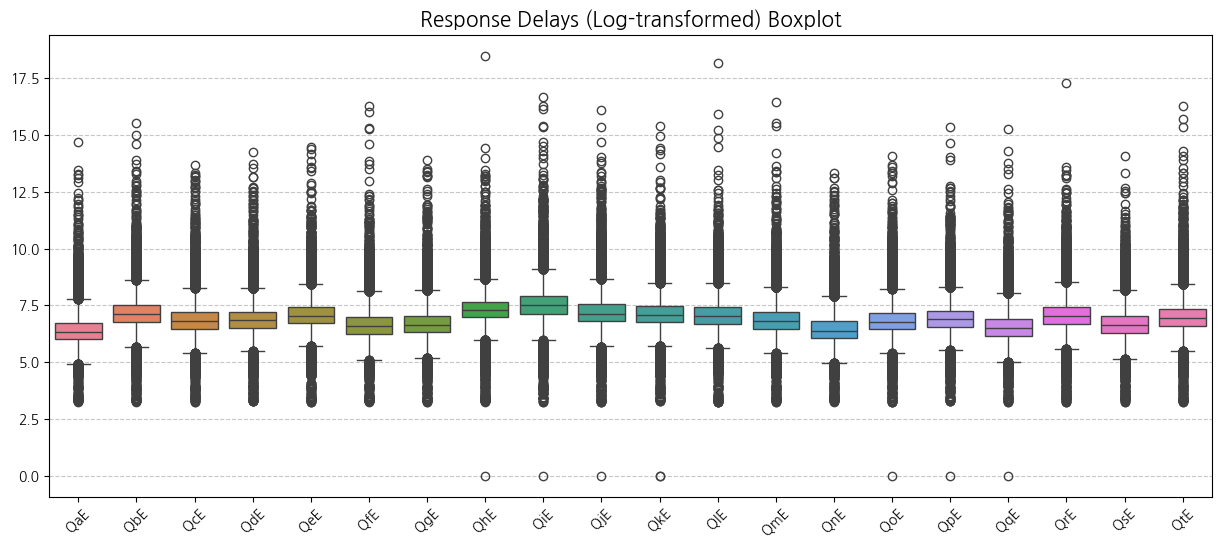

        Column  Outliers  Min           Max  Lower_Bound  Upper_Bound
0   familysize      4916  0.0  2.147484e+09          0.5          4.5
12         QlA      4353  1.0  5.000000e+00          2.5          6.5
4          QdA      3947  1.0  5.000000e+00         -0.5          3.5
2          QbA         0  1.0  5.000000e+00         -3.5          8.5
1          QaA         0  1.0  5.000000e+00         -2.0          6.0
3          QcA         0  1.0  5.000000e+00         -2.5          9.5
5          QeA         0  1.0  5.000000e+00         -2.0          6.0
7          QgA         0  1.0  5.000000e+00         -3.5          8.5
6          QfA         0  1.0  5.000000e+00         -2.0          6.0
8          QhA         0  1.0  5.000000e+00         -3.5          8.5


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 시각화를 위한 함수 정의 (Boxplot)
def plot_boxplots(df, columns, title):
    plt.figure(figsize=(15, 6))
    sns.boxplot(data=df[columns])
    plt.title(title, fontsize=15)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# 2. IQR 기반 이상치 개수 확인 함수
def get_outlier_summary(df, columns):
    summary = []
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # 범위 밖의 데이터 추출
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        summary.append({
            'Column': col,
            'Outliers': len(outliers),
            'Min': df[col].min(),
            'Max': df[col].max(),
            'Lower_Bound': lower_bound,
            'Upper_Bound': upper_bound
        })
    return pd.DataFrame(summary)

# --- 분석 실행 ---

# [A] 마키아벨리즘 문항 (1~5점 척도)
questions = [f'Q{chr(i)}A' for i in range(ord('a'), ord('t')+1)]
plot_boxplots(train, questions, 'Machiavellianism Questions (1-5) Boxplot')

# [B] 가족 수 (Family Size) - 이상치가 극단적인 경우
plot_boxplots(train, ['familysize'], 'Family Size Outlier Check')

# [C] 응답 지연 시간 (Log 변환 후 확인 권장)
# 지연 시간은 편차가 매우 크므로 로그를 취해 박스플롯을 그리는 것이 효과적입니다.
delays = [f'Q{chr(i)}E' for i in range(ord('a'), ord('t')+1)]
train_delays_log = np.log1p(train[delays])
plot_boxplots(train_delays_log, delays, 'Response Delays (Log-transformed) Boxplot')

# 이상치 통계 요약 출력
summary_df = get_outlier_summary(train, ['familysize'] + questions)
print(summary_df.sort_values(by='Outliers', ascending=False).head(10))

In [ ]:
# ══════════════════════════════════════════════════════════════
# Part 2 — Model 1 (VotingClassifier: RF + LGBM + GBM)
# ══════════════════════════════════════════════════════════════

train = pd.read_csv(f'{DATA_DIR}/train.csv')
test  = pd.read_csv(f'{DATA_DIR}/test_x.csv')

train[TARGET] = train[TARGET].map({1: 0, 2: 1})
y_train = train[TARGET]

x_train = train.drop(TARGET, axis=1)
dataset = [x_train, test]

build_features_m1(dataset)

index = test['index'].copy()
for data in dataset:
    data.drop('index', axis=1, inplace=True)

for col in NEEDENCO:
    le = LabelEncoder()
    le.fit(pd.concat([x_train[col].astype(str), test[col].astype(str)]))
    x_train[col] = le.transform(x_train[col].astype(str))
    test[col]    = le.transform(test[col].astype(str))

print(f'x_train: {x_train.shape}, test: {test.shape}')

skf_m1  = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
oof_m1  = np.zeros(len(x_train))

clf1     = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
clf2     = LGBMClassifier(random_state=0, verbose=-1)
clf3     = GradientBoostingClassifier(random_state=0)
soft_vote = VotingClassifier(
    [('rf', clf1), ('lgbm', clf2), ('gbm', clf3)], voting='soft')

for fold, (tr_idx, val_idx) in enumerate(skf_m1.split(x_train, y_train)):
    soft_vote.fit(x_train.iloc[tr_idx], y_train.iloc[tr_idx])
    oof_m1[val_idx] = soft_vote.predict_proba(x_train.iloc[val_idx])[:, 1]
    print(f'  Fold {fold+1} AUC: {roc_auc_score(y_train.iloc[val_idx], oof_m1[val_idx]):.5f}')

m1_oof_auc = roc_auc_score(y_train, oof_m1)
print(f'\nModel1 OOF AUC: {m1_oof_auc:.5f}')

soft_vote.fit(x_train, y_train)
pred_m1 = soft_vote.predict_proba(test)[:, 1]

pd.DataFrame({'index': index, TARGET: pred_m1}).to_csv(f'{DATA_DIR}/model1.csv', index=False)
print('model1.csv 저장 완료')


x_train: (45532, 217), test: (11383, 217)
  Fold 1 AUC: 0.76169
  Fold 2 AUC: 0.76060
  Fold 3 AUC: 0.76653
  Fold 4 AUC: 0.76393
  Fold 5 AUC: 0.76904

Model1 OOF AUC: 0.76427
model1.csv 저장 완료


In [ ]:
# ══════════════════════════════════════════════════════════════
# Part 3 — Model 2 (LGBM: Optuna 튜닝 + RFE × 4 앙상블)
# ══════════════════════════════════════════════════════════════

train = pd.read_csv(f'{DATA_DIR}/train.csv')
test  = pd.read_csv(f'{DATA_DIR}/test_x.csv')

train[TARGET] = train[TARGET].map({1: 0, 2: 1})
y_train = train[TARGET]

x_train = train.drop(TARGET, axis=1)
dataset = [x_train, test]

build_features_m2(dataset)

index = test['index'].copy()
for data in dataset:
    data.drop('index', axis=1, inplace=True)

for col in NEEDENCO:
    le = LabelEncoder()
    le.fit(pd.concat([x_train[col].astype(str), test[col].astype(str)]))
    x_train[col] = le.transform(x_train[col].astype(str))
    test[col]    = le.transform(test[col].astype(str))

# Big Five × gender 교호작용
for data in [x_train, test]:
    data['Es_gender']  = data['Es']  * data['gender']
    data['Con_gender'] = data['Con'] * data['gender']
    data['Op_gender']  = data['Op']  * data['gender']

print(f'x_train: {x_train.shape}')


# ── Optuna LGBM 하이퍼파라미터 튜닝 ─────────────────────────────
print('\n[Optuna] LGBM 하이퍼파라미터 탐색 시작...')

def objective(trial):
    params = {
        'objective'        : 'binary',
        'metric'           : 'auc',
        'verbosity'        : -1,
        'boosting_type'    : 'gbdt',
        'n_estimators'     : trial.suggest_int('n_estimators', 300, 1500),
        'learning_rate'    : trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 150),
        'max_depth'        : trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state'     : 42,
    }
    cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for tr_idx, val_idx in cv.split(x_train, y_train):
        model = LGBMClassifier(**params)
        model.fit(
            x_train.iloc[tr_idx], y_train.iloc[tr_idx],
            eval_set=[(x_train.iloc[val_idx], y_train.iloc[val_idx])],
            callbacks=[early_stopping(50, verbose=False)],
        )
        pred   = model.predict_proba(x_train.iloc[val_idx])[:, 1]
        scores.append(roc_auc_score(y_train.iloc[val_idx], pred))
    return np.mean(scores)

study = optuna.create_study(direction='maximize',
                            sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params
best_params.update({'objective': 'binary', 'verbosity': -1,
                    'boosting_type': 'gbdt', 'random_state': 42})
print(f'\n최적 파라미터: {best_params}')
print(f'최적 CV AUC : {study.best_value:.5f}')


# ── LGBM RFE 함수 (Optuna 파라미터 적용) ───────────────────────
def lgbm_rfe(x_data, y_data, params, ratio=0.9, min_feats=40):
    feats   = x_data.columns.tolist()
    archive = pd.DataFrame(columns=['model', 'n_feats', 'feats', 'score'])
    while True:
        model = LGBMClassifier(**params)
        X_tr, X_val, y_tr, y_val = train_test_split(
            x_data[feats], y_data, random_state=params.get('random_state', 42))
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  callbacks=[early_stopping(100, verbose=False)])
        val_pred = model.predict_proba(X_val)[:, 1]
        score    = roc_auc_score(y_val, val_pred)
        n_feats  = len(feats)
        print(f'  피처수={n_feats:4d}  val AUC={score:.5f}')
        archive.loc[len(archive)] = [model, n_feats, feats, score]
        feat_imp     = pd.Series(
            model.feature_importances_, index=feats).sort_values(ascending=False)
        next_n_feats = int(n_feats * ratio)
        if next_n_feats < min_feats:
            break
        feats = feat_imp.iloc[:next_n_feats].index.tolist()
    return archive


for rs in [4040, 1234, 99087, 42]:
    p = {**best_params, 'random_state': rs}
    label = f'RFE {rs}'
    print(f'\n[{label}]')
    if rs == 4040:
        arch_4040  = lgbm_rfe(x_train, y_train, p)
    elif rs == 1234:
        arch_1234  = lgbm_rfe(x_train, y_train, p)
    elif rs == 99087:
        arch_99087 = lgbm_rfe(x_train, y_train, p)
    else:
        arch_42    = lgbm_rfe(x_train, y_train, p)

print('\nRFE 완료')

best_idx_4040  = arch_4040['score'].idxmax()
best_idx_1234  = arch_1234['score'].idxmax()
best_idx_99087 = arch_99087['score'].idxmax()
best_idx_42    = arch_42['score'].idxmax()


def fit_predict(archive, best_idx, x_tr, y_tr, x_te, params):
    feats = archive.iloc[best_idx, 2]
    model = LGBMClassifier(**params)
    model.fit(x_tr[feats], y_tr)
    return model.predict_proba(x_te[feats])[:, 1], model, feats


pred_y1, m1r, f1 = fit_predict(arch_4040,  best_idx_4040,  x_train, y_train, test,
                                {**best_params, 'random_state': 4040})
pred_y2, m2r, f2 = fit_predict(arch_1234,  best_idx_1234,  x_train, y_train, test,
                                {**best_params, 'random_state': 1234})
pred_y3, m3r, f3 = fit_predict(arch_99087, best_idx_99087, x_train, y_train, test,
                                {**best_params, 'random_state': 99087})
pred_y4, m4r, f4 = fit_predict(arch_42,    best_idx_42,    x_train, y_train, test,
                                {**best_params, 'random_state': 42})

# OOF AUC
skf_m2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
oof_m2 = np.zeros(len(x_train))

for fold, (tr_idx, val_idx) in enumerate(skf_m2.split(x_train, y_train)):
    fold_pred = np.zeros(len(val_idx))
    for feats, rs in [(f1, 4040), (f2, 1234), (f3, 99087), (f4, 42)]:
        m = LGBMClassifier(**{**best_params, 'random_state': rs})
        m.fit(x_train[feats].iloc[tr_idx], y_train.iloc[tr_idx])
        fold_pred += m.predict_proba(x_train[feats].iloc[val_idx])[:, 1] / 4
    oof_m2[val_idx] = fold_pred
    print(f'  Fold {fold+1} AUC: {roc_auc_score(y_train.iloc[val_idx], fold_pred):.5f}')

m2_oof_auc = roc_auc_score(y_train, oof_m2)
print(f'\nModel2 OOF AUC: {m2_oof_auc:.5f}')

pred_all = (pred_y1 + pred_y2 + pred_y3 + pred_y4) / 4
pd.DataFrame({'index': index, TARGET: pred_all}).to_csv(
    f'{DATA_DIR}/model2.csv', index=False)
print('model2.csv 저장 완료')

x_train: (45532, 350)

[Optuna] LGBM 하이퍼파라미터 탐색 시작...


  0%|          | 0/50 [00:00<?, ?it/s]


최적 파라미터: {'n_estimators': 606, 'learning_rate': 0.016186216154528983, 'num_leaves': 54, 'max_depth': 12, 'min_child_samples': 54, 'subsample': 0.6444992913523369, 'colsample_bytree': 0.4780959149810915, 'reg_alpha': 8.070822000898519e-07, 'reg_lambda': 0.0023154867171186412, 'objective': 'binary', 'verbosity': -1, 'boosting_type': 'gbdt', 'random_state': 42}
최적 CV AUC : 0.76952

[RFE 4040]
  피처수= 350  val AUC=0.77070
  피처수= 315  val AUC=0.76907
  피처수= 283  val AUC=0.76804
  피처수= 254  val AUC=0.76915
  피처수= 228  val AUC=0.76842
  피처수= 205  val AUC=0.76872
  피처수= 184  val AUC=0.76767
  피처수= 165  val AUC=0.77068
  피처수= 148  val AUC=0.76989
  피처수= 133  val AUC=0.76837
  피처수= 119  val AUC=0.76845
  피처수= 107  val AUC=0.76770
  피처수=  96  val AUC=0.76771
  피처수=  86  val AUC=0.76841
  피처수=  77  val AUC=0.76863
  피처수=  69  val AUC=0.76682
  피처수=  62  val AUC=0.76531
  피처수=  55  val AUC=0.76344
  피처수=  49  val AUC=0.76094
  피처수=  44  val AUC=0.76104

[RFE 1234]
  피처수= 350  val AUC=0.76426
  피처수=

In [ ]:
# ══════════════════════════════════════════════════════════════
# Part 4 — Model 3 (NN: 개선된 구조 + Label Smoothing + SWA)
# ══════════════════════════════════════════════════════════════

random.seed(0); np.random.seed(0); torch.manual_seed(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'\n디바이스: {DEVICE}')

DROP_COLS   = DELAYS + ['index', 'hand']
NN_CAT_COLS = ['education', 'engnat', 'married', 'urban']

train_data = pd.read_csv(f'{DATA_DIR}/train.csv')
test_data  = pd.read_csv(f'{DATA_DIR}/test_x.csv')

train_data[TARGET] = train_data[TARGET].map({1: 0, 2: 1})

# familysize 이상치 제거
train_data = train_data.drop(
    train_data[train_data.familysize > 50].index).reset_index(drop=True)

train_y_raw = train_data[TARGET]
train_x_raw = train_data.drop(DROP_COLS + [TARGET], axis=1)
test_x_raw  = test_data.drop(DROP_COLS, axis=1)

for col in NN_CAT_COLS:
    train_x_raw[col] = train_x_raw[col].astype(str)
    test_x_raw[col]  = test_x_raw[col].astype(str)

n_train  = len(train_x_raw)
combined = pd.get_dummies(
    pd.concat([train_x_raw, test_x_raw], axis=0, ignore_index=True))
train_x_df = combined.iloc[:n_train].reset_index(drop=True)
test_x_df  = combined.iloc[n_train:].reset_index(drop=True)
train_x_df, test_x_df = train_x_df.align(
    test_x_df, join='left', axis=1, fill_value=0)

print(f'피처 수: {train_x_df.shape[1]}  '
      f'(컬럼 일치: {list(train_x_df.columns) == list(test_x_df.columns)})')

# 정규화
col_list = list(train_x_df.columns)
qa_idx = [col_list.index(c) for c in col_list
          if len(c) == 3 and c[0] == 'Q' and c[2] == 'A']
fs_idx = col_list.index('familysize') if 'familysize' in col_list else None
tp_idx = [col_list.index(c) for c in [f'tp{str(i).zfill(2)}' for i in range(1, 11)]
          if c in col_list]

train_x = train_x_df.to_numpy(dtype=np.float32)
test_x  = test_x_df.to_numpy(dtype=np.float32)

if qa_idx:
    train_x[:, qa_idx] = (train_x[:, qa_idx] - 3.) / 2.
    test_x[:, qa_idx]  = (test_x[:, qa_idx]  - 3.) / 2.
if fs_idx is not None:
    train_x[:, fs_idx] = (train_x[:, fs_idx] - 5.) / 4.
    test_x[:, fs_idx]  = (test_x[:, fs_idx]  - 5.) / 4.
if tp_idx:
    train_x[:, tp_idx] = (train_x[:, tp_idx] - 3.5) / 3.5
    test_x[:, tp_idx]  = (test_x[:, tp_idx]  - 3.5) / 3.5

train_y   = train_y_raw.to_numpy().astype(np.float32)
INPUT_DIM = train_x.shape[1]
print(f'input_dim: {INPUT_DIM}')

train_x_t = torch.tensor(train_x, dtype=torch.float32)
train_y_t = torch.tensor(train_y, dtype=torch.float32)
test_x_t  = torch.tensor(test_x,  dtype=torch.float32)
test_len  = len(test_x_t)


# ── 개선된 NN 아키텍처 ─────────────────────────────────────────

class ResidualBlock(nn.Module):
    """잔차 블록: skip connection으로 깊은 네트워크 학습 안정화"""
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim, bias=False),
            nn.BatchNorm1d(dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim, bias=False),
            nn.BatchNorm1d(dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.net(x))


class ImprovedNN(nn.Module):
    """
    개선 사항:
      - BatchNorm + GELU 활성화로 학습 안정화
      - ResidualBlock으로 그래디언트 소실 방지
      - 입력 BN으로 피처 스케일 정규화
    """
    def __init__(self, input_dim):
        super().__init__()
        self.stem = nn.Sequential(
            nn.BatchNorm1d(input_dim),
            nn.Dropout(0.05),
            nn.Linear(input_dim, 256, bias=False),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.4),
        )
        self.res1   = ResidualBlock(256, dropout=0.3)
        self.down1  = nn.Sequential(
            nn.Linear(256, 128, bias=False),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.3),
        )
        self.res2   = ResidualBlock(128, dropout=0.25)
        self.down2  = nn.Sequential(
            nn.Linear(128, 64, bias=False),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(0.2),
        )
        self.head   = nn.Linear(64, 1)

    def forward(self, x):
        x = self.stem(x)
        x = self.res1(x)
        x = self.down1(x)
        x = self.res2(x)
        x = self.down2(x)
        return self.head(x)


class LabelSmoothingBCE(nn.Module):
    """Label Smoothing: 과적합 방지"""
    def __init__(self, smoothing=0.05, pos_weight=None):
        super().__init__()
        self.smoothing  = smoothing
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        targets_smooth = targets * (1 - self.smoothing) + 0.5 * self.smoothing
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets_smooth,
            pos_weight=self.pos_weight)
        return bce


N_REPEAT   = 5
N_SKFOLD   = 7
N_EPOCH    = 60           # ★ 에폭 증가
BATCH_SIZE = 128          # ★ 배치 크기 증가 (BN 안정화)
LOADER_PARAM = {'batch_size': BATCH_SIZE, 'num_workers': 0,
                'pin_memory': DEVICE != 'cpu'}

prediction = np.zeros((test_len, 1), dtype=np.float32)
oof_nn3    = np.zeros(len(train_y))
oof_counts = np.zeros(len(train_y))

for repeat in range(N_REPEAT):
    skf = StratifiedKFold(n_splits=N_SKFOLD, random_state=repeat, shuffle=True)
    tot = 0.
    for skfold, (train_idx, valid_idx) in enumerate(skf.split(train_x, train_y)):
        train_loader = DataLoader(
            TensorDataset(train_x_t[train_idx], train_y_t[train_idx]),
            shuffle=True, drop_last=True, **LOADER_PARAM)
        valid_loader = DataLoader(
            TensorDataset(train_x_t[valid_idx], train_y_t[valid_idx]),
            shuffle=False, drop_last=False, **LOADER_PARAM)
        test_loader  = DataLoader(
            TensorDataset(test_x_t, torch.zeros(test_len, dtype=torch.float32)),
            shuffle=False, drop_last=False, **LOADER_PARAM)

        model     = ImprovedNN(INPUT_DIM).to(DEVICE)
        criterion = LabelSmoothingBCE(
            smoothing=0.05,
            pos_weight=torch.tensor([1.20665], device=DEVICE))

        # ★ AdamW + OneCycleLR 스케줄러
        optimizer = optim.AdamW(
            model.parameters(), lr=1e-3, weight_decay=5e-2)
        scheduler = optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=5e-3,
            steps_per_epoch=len(train_loader),
            epochs=N_EPOCH, pct_start=0.3)

        # ★ SWA (Stochastic Weight Averaging)
        swa_model = optim.swa_utils.AveragedModel(model)
        swa_start = int(N_EPOCH * 0.75)
        swa_scheduler = optim.swa_utils.SWALR(
            optimizer, swa_lr=1e-4, anneal_epochs=5)

        prediction_t   = np.zeros((test_len, 1), dtype=np.float32)
        best_auc       = 0.
        best_val_probs = np.zeros(len(valid_idx))

        for epoch in tqdm(range(N_EPOCH),
                          desc=f'R{repeat+1} S{skfold+1:02d}/{N_SKFOLD}'):
            model.train()
            for xx, yy in train_loader:
                optimizer.zero_grad()
                loss = criterion(
                    model(xx.to(DEVICE)).squeeze(), yy.to(DEVICE))
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # ★ gradient clip
                optimizer.step()
                if epoch < swa_start:
                    scheduler.step()

            # SWA 업데이트
            if epoch >= swa_start:
                swa_model.update_parameters(model)
                swa_scheduler.step()

            # 검증
            eval_model = swa_model if epoch >= swa_start else model
            eval_model.eval()
            val_probs = []
            with torch.no_grad():
                for xx, _ in valid_loader:
                    out = eval_model(xx.to(DEVICE)).squeeze()
                    val_probs.append(torch.sigmoid(out).cpu().numpy())

            val_probs_cat = np.concatenate(val_probs)
            val_auc       = roc_auc_score(train_y[valid_idx], val_probs_cat)

            if val_auc > best_auc:
                best_auc       = val_auc
                best_val_probs = val_probs_cat
                tmp_preds = []
                with torch.no_grad():
                    for xx, _ in test_loader:
                        tmp_preds.append(
                            torch.sigmoid(eval_model(xx.to(DEVICE))).cpu().numpy())
                prediction_t = np.vstack(tmp_preds)

        # SWA BN 업데이트
        optim.swa_utils.update_bn(train_loader, swa_model, device=DEVICE)

        prediction[:, :] += prediction_t[:, :] / (N_REPEAT * N_SKFOLD)
        oof_nn3[valid_idx] += best_val_probs / N_REPEAT
        oof_counts[valid_idx] += 1
        tot += best_auc

    print(f'Repeat {repeat+1} → avg best AUC: {tot/N_SKFOLD:.4f}')

m3_oof_auc = roc_auc_score(train_y, oof_nn3)
print(f'\nModel3 (NN) OOF AUC: {m3_oof_auc:.5f}')

test_index = pd.read_csv(f'{DATA_DIR}/test_x.csv')['index']
pd.DataFrame({'index': test_index, TARGET: prediction.squeeze()}).to_csv(
    f'{DATA_DIR}/model3.csv', index=False)
print('model3.csv 저장 완료')

In [ ]:
# ══════════════════════════════════════════════════════════════
# Part 5 — 최적 앙상블 가중치 탐색 + 최종 앙상블
# ══════════════════════════════════════════════════════════════

model1 = pd.read_csv(f'{DATA_DIR}/model1.csv', index_col='index')
model2 = pd.read_csv(f'{DATA_DIR}/model2.csv', index_col='index')
model3 = pd.read_csv(f'{DATA_DIR}/model3.csv', index_col=None)

test_idx = pd.read_csv(f'{DATA_DIR}/test_x.csv')['index']

# OOF 예측값으로 최적 가중치 탐색
print('\n[앙상블 가중치 최적화]')
print(f'  Model1 OOF AUC: {m1_oof_auc:.5f}')
print(f'  Model2 OOF AUC: {m2_oof_auc:.5f}')
print(f'  Model3 OOF AUC: {m3_oof_auc:.5f}')

# oof_m1, oof_m2, oof_nn3 → Optuna로 최적 가중치 탐색
train_data_reload = pd.read_csv(f'{DATA_DIR}/train.csv')
train_data_reload[TARGET] = train_data_reload[TARGET].map({1: 0, 2: 1})

# NN OOF는 familysize > 50 행이 제거돼 있으므로 정렬 필요
# 간단히 공통 인덱스 기반으로 재정렬
full_y = train_data_reload[TARGET].values

# oof_m1, oof_m2는 full train 기준, oof_nn3는 filtered 기준
# filtered idx 재구성
nn_filter_mask = train_data_reload['familysize'] <= 50
nn_full_oof    = np.full(len(full_y), np.nan)
nn_full_oof[nn_filter_mask.values] = oof_nn3

# nan 행 제거 후 가중치 탐색
valid_mask = ~np.isnan(nn_full_oof)
y_sub      = full_y[valid_mask]
o1_sub     = oof_m1[valid_mask]
o2_sub     = oof_m2[valid_mask]
o3_sub     = nn_full_oof[valid_mask]

def weight_objective(trial):
    w1 = trial.suggest_float('w1', 0.0, 1.0)
    w2 = trial.suggest_float('w2', 0.0, 1.0)
    w3 = trial.suggest_float('w3', 0.0, 1.0)
    total = w1 + w2 + w3
    if total == 0:
        return 0.0
    blend = (w1 * o1_sub + w2 * o2_sub + w3 * o3_sub) / total
    return roc_auc_score(y_sub, blend)

w_study = optuna.create_study(direction='maximize',
                              sampler=TPESampler(seed=0))
w_study.optimize(weight_objective, n_trials=300, show_progress_bar=False)

wbest = w_study.best_params
w_total = wbest['w1'] + wbest['w2'] + wbest['w3']
W1 = wbest['w1'] / w_total
W2 = wbest['w2'] / w_total
W3 = wbest['w3'] / w_total

print(f'\n최적 앙상블 가중치:')
print(f'  Model1: {W1:.4f}  Model2: {W2:.4f}  Model3: {W3:.4f}')
print(f'  최적 OOF AUC (Optuna): {w_study.best_value:.5f}')

In [ ]:
# 테스트 예측 앙상블
m3_pred   = model3.iloc[:, 1].values
pred_final = (W1 * pred_m1 +
              W2 * pred_all +
              W3 * m3_pred)

submission = pd.DataFrame({'index': test_idx, TARGET: pred_final})
submission.to_csv(f'{DATA_DIR}/submission_final_final.csv', index=False)

print('\n=== 모델별 OOF AUC 요약 ===')
print(f'  Model1 (Voting)   : {m1_oof_auc:.5f}')
print(f'  Model2 (LGBM RFE) : {m2_oof_auc:.5f}')
print(f'  Model3 (NN)       : {m3_oof_auc:.5f}')
print(f'  앙상블 OOF AUC    : {w_study.best_value:.5f}')
print(f'\n최종 앙상블 저장 완료: submission_final_final.csv')
print(submission.head())

In [ ]:
# ══════════════════════════════════════════════════════════════
# Feature Importance 추출 및 시각화
# ══════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.inspection import permutation_importance

# 한글 폰트 설정 (Colab 기준)
# !apt-get install -y fonts-nanum -qq
# fm._rebuild()
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

TOP_N = 30  # 상위 N개 피처 표시

# ─────────────────────────────────────────────────────────────
# 공통 시각화 함수
# ─────────────────────────────────────────────────────────────

def plot_importance(importances: pd.Series, title: str, top_n: int = TOP_N,
                    color: str = 'steelblue', figsize=(10, 8)):
    """수평 막대그래프로 피처 중요도 시각화"""
    top = importances.nlargest(top_n).sort_values()
    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.barh(top.index, top.values, color=color, edgecolor='white', linewidth=0.5)

    # 값 레이블
    for bar, val in zip(bars, top.values):
        ax.text(val + top.values.max() * 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8)

    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('Importance', fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


def plot_importance_comparison(imp_dict: dict, top_n: int = 20, figsize=(16, 7)):
    """여러 모델의 피처 중요도를 나란히 비교"""
    n_models = len(imp_dict)
    fig, axes = plt.subplots(1, n_models, figsize=figsize)
    if n_models == 1:
        axes = [axes]

    colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']
    for ax, (name, imp), color in zip(axes, imp_dict.items(), colors):
        top = imp.nlargest(top_n).sort_values()
        ax.barh(top.index, top.values, color=color, edgecolor='white', linewidth=0.5)
        ax.set_title(name, fontsize=12, fontweight='bold')
        ax.set_xlabel('Importance')
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(axis='x', linestyle='--', alpha=0.4)

    plt.suptitle(f'모델별 피처 중요도 Top {top_n} 비교', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────
# Model 1 — VotingClassifier 내 LGBM 피처 중요도
# ─────────────────────────────────────────────────────────────

print('=' * 60)
print('Model 1: VotingClassifier — LGBM 피처 중요도')
print('=' * 60)

# soft_vote 내 LGBM 추출
lgbm_in_vote = soft_vote.named_estimators_['lgbm']

imp_m1 = pd.Series(
    lgbm_in_vote.feature_importances_,
    index=x_train.columns          # Model1 피처 기준
).sort_values(ascending=False)

print(f'\nTop 10 피처 (Model 1):\n{imp_m1.head(10).to_string()}')
plot_importance(imp_m1, 'Model 1 — LGBM Feature Importance (gain)', color='steelblue')

# RF 중요도도 함께 확인
rf_in_vote = soft_vote.named_estimators_['rf']
imp_m1_rf = pd.Series(
    rf_in_vote.feature_importances_,
    index=x_train.columns
).sort_values(ascending=False)
plot_importance(imp_m1_rf, 'Model 1 — RandomForest Feature Importance', color='slategray')


# ─────────────────────────────────────────────────────────────
# Model 2 — LGBM RFE 4개 모델 피처 중요도 (평균)
# ─────────────────────────────────────────────────────────────

print('\n' + '=' * 60)
print('Model 2: LGBM RFE — 피처 중요도 (4개 시드 평균)')
print('=' * 60)

# 각 RFE 최적 모델에서 중요도 수집
rfe_models = [
    (m1r, f1, 'RFE seed=4040'),
    (m2r, f2, 'RFE seed=1234'),
    (m3r, f3, 'RFE seed=99087'),
    (m4r, f4, 'RFE seed=42'),
]

imp_rfe_dict = {}
for model, feats, label in rfe_models:
    imp = pd.Series(
        model.feature_importances_,
        index=feats
    ).sort_values(ascending=False)
    imp_rfe_dict[label] = imp
    print(f'\n{label} Top 5: {imp.head(5).index.tolist()}')

# 4개 모델 평균 중요도
all_feats = set()
for imp in imp_rfe_dict.values():
    all_feats.update(imp.index)

imp_m2_avg = pd.Series(0.0, index=sorted(all_feats))
for imp in imp_rfe_dict.values():
    imp_m2_avg = imp_m2_avg.add(imp, fill_value=0)
imp_m2_avg /= len(rfe_models)
imp_m2_avg = imp_m2_avg.sort_values(ascending=False)

print(f'\nTop 10 피처 (Model 2 평균):\n{imp_m2_avg.head(10).to_string()}')
plot_importance(imp_m2_avg, 'Model 2 — LGBM RFE 평균 Feature Importance', color='darkorange')

# 4개 시드별 비교
plot_importance_comparison(imp_rfe_dict, top_n=15, figsize=(20, 6))


# ─────────────────────────────────────────────────────────────
# Model 3 — NN Permutation Importance
# (NN은 내장 feature_importances_ 없음 → permutation 방식 사용)
# ─────────────────────────────────────────────────────────────

print('\n' + '=' * 60)
print('Model 3: NN — Permutation Feature Importance')
print('=' * 60)

class NNWrapper:
    """sklearn 호환 래퍼 (permutation_importance 사용용)"""
    def __init__(self, model, device):
        self.model  = model
        self.device = device

    def predict_proba(self, X):
        self.model.eval()
        with torch.no_grad():
            t = torch.tensor(X, dtype=torch.float32).to(self.device)
            prob = torch.sigmoid(self.model(t)).cpu().numpy().squeeze()
        return np.column_stack([1 - prob, prob])

    def fit(self, X, y):          # sklearn 형식 호환용
        return self

# 마지막 fold의 swa_model 사용 (학습 완료 상태)
nn_wrapper = NNWrapper(swa_model, DEVICE)

# 샘플링 (속도 향상: 최대 2000개)
N_PERM_SAMPLE = min(2000, len(train_x))
rng    = np.random.default_rng(42)
perm_idx = rng.choice(len(train_x), N_PERM_SAMPLE, replace=False)

X_perm = train_x[perm_idx]
y_perm = train_y[perm_idx].astype(int)

print(f'Permutation importance 계산 중... (샘플 {N_PERM_SAMPLE}개, n_repeats=10)')
perm_result = permutation_importance(
    nn_wrapper, X_perm, y_perm,
    n_repeats=10,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
)

imp_m3 = pd.Series(
    perm_result.importances_mean,
    index=list(train_x_df.columns)
).sort_values(ascending=False)

# 음수 (성능에 무관한 피처) 제외 옵션
imp_m3_pos = imp_m3[imp_m3 > 0]

print(f'\nTop 10 피처 (Model 3 NN):\n{imp_m3_pos.head(10).to_string()}')
plot_importance(imp_m3_pos, 'Model 3 — NN Permutation Feature Importance', color='seagreen')


# ─────────────────────────────────────────────────────────────
# 통합 비교: 3개 모델 공통 피처 중요도 (정규화 후 평균)
# ─────────────────────────────────────────────────────────────

print('\n' + '=' * 60)
print('통합: 3개 모델 피처 중요도 정규화 앙상블')
print('=' * 60)

def normalize_importance(imp: pd.Series) -> pd.Series:
    """0~1 정규화"""
    rng_val = imp.max() - imp.min()
    return (imp - imp.min()) / rng_val if rng_val > 0 else imp * 0

norm_m1 = normalize_importance(imp_m1)
norm_m2 = normalize_importance(imp_m2_avg)
norm_m3 = normalize_importance(imp_m3_pos)

# 공통 피처만 평균
common_feats = norm_m1.index.intersection(norm_m2.index).intersection(norm_m3.index)
print(f'공통 피처 수: {len(common_feats)}')

if len(common_feats) > 0:
    norm_avg = (norm_m1[common_feats] + norm_m2[common_feats] + norm_m3[common_feats]) / 3
    norm_avg = norm_avg.sort_values(ascending=False)
    print(f'\nTop 10 통합 중요 피처:\n{norm_avg.head(10).to_string()}')
    plot_importance(norm_avg, '통합 — 3개 모델 정규화 평균 Feature Importance', color='mediumpurple')
else:
    print('공통 피처가 없어 Model 2 기준으로 표시합니다.')
    plot_importance(norm_m2, 'Model 2 — Feature Importance (대표)', color='darkorange')


# ─────────────────────────────────────────────────────────────
# 피처 중요도 히트맵 (Model 2 RFE 4개 시드 비교)
# ─────────────────────────────────────────────────────────────

print('\n피처 중요도 히트맵 (Model 2 RFE 시드별)')

top_feats_union = imp_m2_avg.head(25).index.tolist()
heatmap_df = pd.DataFrame({
    label: imp.reindex(top_feats_union).fillna(0)
    for label, imp in imp_rfe_dict.items()
})

# 정규화
heatmap_norm = heatmap_df.div(heatmap_df.max(axis=0))

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(heatmap_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Normalized Importance'})
ax.set_title('Model 2 RFE — 시드별 피처 중요도 히트맵 (Top 25)', fontsize=13, fontweight='bold')
ax.set_xlabel('모델 (시드)')
ax.set_ylabel('피처')
plt.tight_layout()
plt.show()

print('\n피처 중요도 분석 완료!')

Model 1: VotingClassifier — LGBM 피처 중요도


NameError: name 'soft_vote' is not defined